Step 1: Fetching the website...
✓ Website loaded successfully!
✓ Found 20 book boxes to scrape.
Step 2: Scraping data from each box...
Step 3: Organizing data into a table...

📊 Data Analysis Results:
Average Price: 38.048500000000004
Highest Price: 57.25
Lowest Price: 13.99
✓ SUCCESS! File saved as 'my_first_scraped_books.csv'

Preview:

                              Book Title  Price (UK Pounds)
0                   A Light in the Attic              51.77
1                     Tipping the Velvet              53.74
2                             Soumission              50.10
3                          Sharp Objects              47.82
4  Sapiens: A Brief History of Humankind              54.23


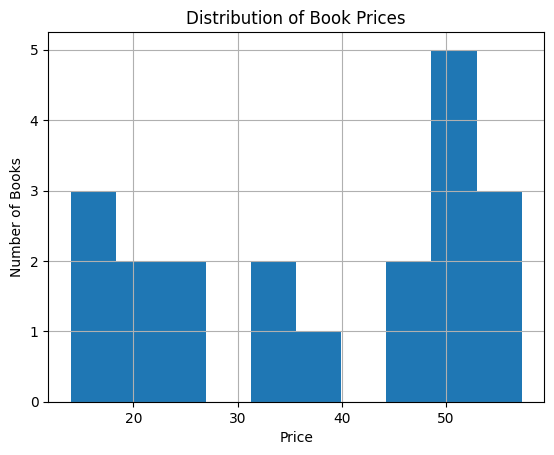

In [6]:
# -*- coding: utf-8 -*-
"""Project 1: My First Web Scraper - Gets Book Titles & Prices."""

# STEP 1: Import the tools (like getting your toolbox ready)
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

# STEP 2: Tell the computer which website to visit
print("Step 1: Fetching the website...")
url = 'http://books.toscrape.com/'
response = requests.get(url)

# STEP 3: Check if the website answered
if response.status_code == 200:
    print("✓ Website loaded successfully!")

    soup = BeautifulSoup(response.text, 'html.parser')

    book_boxes = soup.find_all('article', class_='product_pod')
    print(f"✓ Found {len(book_boxes)} book boxes to scrape.")

    list_of_titles = []
    list_of_prices = []

    print("Step 2: Scraping data from each box...")
    for box in book_boxes:
        title_tag = box.h3.a['title']
        price_tag = box.find('p', class_='price_color').text

        list_of_titles.append(title_tag)
        list_of_prices.append(price_tag)

    print("Step 3: Organizing data into a table...")
    data_table = pd.DataFrame({
        'Book Title': list_of_titles,
        'Price (UK Pounds)': list_of_prices
    })

    # CLEANING
    data_table['Price (UK Pounds)'] = data_table['Price (UK Pounds)'].str.replace('Â£', '').str.replace('£', '')
    data_table['Price (UK Pounds)'] = data_table['Price (UK Pounds)'].astype(float)

    # ANALYSIS
    print("\n📊 Data Analysis Results:")
    print("Average Price:", data_table['Price (UK Pounds)'].mean())
    print("Highest Price:", data_table['Price (UK Pounds)'].max())
    print("Lowest Price:", data_table['Price (UK Pounds)'].min())

    # SAVE
    file_name = 'my_first_scraped_books.csv'
    data_table.to_csv(file_name, index=False, encoding='utf-8')

    print(f"✓ SUCCESS! File saved as '{file_name}'")
    print("\nPreview:\n")
    print(data_table.head())

    # GRAPH
    import matplotlib.pyplot as plt
    plt.figure()
    data_table['Price (UK Pounds)'].hist()
    plt.title("Distribution of Book Prices")
    plt.xlabel("Price")
    plt.ylabel("Number of Books")
    plt.show()

else:
    print(f"✗ Failed to load website. Error code: {response.status_code}")